# Machine Translation - Inference

Uncomment this if you are using Colab. Please reserve at least 80GB storage.

In [21]:
# from google.colab import drive
# drive.mount('/content/drive')

In [22]:
# cd /content/drive/MyDrive/Machine Learning/Project

In [23]:
import os, json, math, time
import dotenv
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    EarlyStoppingCallback,
    AutoModelForSeq2SeqLM,
    GenerationConfig
)
import torch
import numpy as np
import random
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import jsonlines

dotenv.load_dotenv('.env')
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

## Load Dataset WMT17

Device space limitation.

In [67]:
target_language_code = "eng_Latn" # BCP-47 code for English


In [24]:
SUPPORTED_LANGS = ['zh-en'] #'cs-en', 'de-en', 'fi-en', 'lv-en', 'ru-en', 'tr-en', ]
lang_map = {
        'en': 'en_XX',
        'zh': 'zh_CN',
        'cs': 'cs_CZ',
        'de': 'de_DE',
        'fi': 'fi_FI',
        'lv': 'lv_LV',
        'ru': 'ru_RU',
        'tr': 'tr_TR',
    }
model_map = {
    # 'mbart': 'facebook/mbart-large-50-many-to-many-mmt',
    # 'opus-mt': 'Helsinki-NLP/opus-mt-zh-en',
    'nllb': 'facebook/nllb-200-distilled-600M',
}
# Set the best model parameters here!
model_params = {
    # 'mbart': {'num_train': 2048},
    # 'opus-mt': {'num_train': 2048},
    'nllb': {'num_train': 2048},
}

## Load Pretrained Model.

| Model key | HF model id                              | # Params | Arch.                     | Languages             | Pre-train data        | Tokeniser           | Requires prompt prefix?    | Size on disk |
| --------- | ---------------------------------------- | -------- | ------------------------- | --------------------- | --------------------- | ------------------- | -------------------------- | ------------ |
| mbart     | facebook/mbart-large-50-many-to-many-mmt | 610 M    | Transformer-large (12-12) | 50 langs, any→any     | CC25 + mined data     | SentencePiece 250 k | No (src/tgt codes in call) | ~2.3 GB      |
| opus-mt   | Helsinki-NLP/opus-mt-zh-en               | 74 M     | Transformer-base (6-6)    | zh → en only          | OPUS corpus           | SentencePiece 32 k  | No                         | ~298 MB      |
| nllb      | facebook/nllb-200-distilled-1.3B         | 1.3 B    | Transformer (12-12, MoE)  | 200 langs, any→any    | NLLB-200 corpus       | SentencePiece 256 k | No                         | ~5 GB        |
| t5-small  | google-t5/t5-small                       | 60 M     | Encoder-decoder (6-6)     | any pair in pre-train | C4 + downstream tasks | SentencePiece 32 k  | Yes ("translate X to Y:")  | ~242 MB      |


In [26]:
import random
import os
import numpy as np
import torch

def seed_all(seed: int = 42):
    # 1. Python builtin
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    # 2. NumPy
    np.random.seed(seed)

    # 3. PyTorch
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    print(f"[seed_all] Global random seed set to {seed}")

## Load MT Metrics

In [27]:
from evaluate import load

bleu = load("sacrebleu", cache_dir='./cache')
chrf = load("chrf", cache_dir='./cache')


## Preprocess Datasets

In [28]:
def split_train_test(full_train, num_trains, num_test, num_val):
    indices = random.sample(range(len(full_train)), num_trains + num_test + num_val)
    raw_train = full_train.select(indices[:num_trains])
    raw_test = full_train.select(indices[num_trains:num_trains + num_test])
    raw_val = full_train.select(indices[num_trains + num_test:])
    return raw_train, raw_test, raw_val


In [29]:
def flip_dataset(raw, src, tgt):
    def flip(batch):
        batch["translation"] = {src: batch["translation"][tgt],
                                tgt: batch["translation"][src]}
        return batch
    return raw.map(flip, batched=False)


In [30]:
def clean_memory():
    import torch, gc
    if torch.cuda.is_available():
        torch.cuda.empty_cache()  # 把未用缓存还给 CUDA
    elif torch.backends.mps.is_available():
        torch.mps.empty_cache()   # 把未用缓存还给 CUDA
    gc.collect()               # 再让 Python 回收一次

In [31]:
data = load_dataset("wmt17", name='zh-en', split="train", cache_dir='./cache')


## Run Inference

Obtain the input setences.

In [33]:
dataset = load_dataset('wmt17', 'zh-en', split='test', cache_dir='./cache')

In [34]:
seed_all(111) # Set a seed to 111.

[seed_all] Global random seed set to 111


In [35]:
len(dataset)

2001

In [36]:
num_inputs = 5 # Fixed to 5.

input_data = dataset.select(random.choices(range(len(dataset)), k=num_inputs))
len(input_data)

5

In [37]:
input_data

Dataset({
    features: ['translation'],
    num_rows: 5
})

In [38]:
def get_avail_device():
    if torch.cuda.is_available():
        device = torch.device("cuda")
    elif torch.mps.is_available():
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
    return device

In [68]:
import torch
from tqdm.auto import tqdm

@torch.no_grad()
def translate(model, model_name, tok, input_data, src='zh'):
    model.eval()
    device = get_avail_device()
    target_lang_id = tok.convert_tokens_to_ids(target_language_code)

    # 1. 生成参数（可按需调）
    # gen_kwargs = {
    #     "max_length": 64,
    #     "num_beams": 4,
    #     "early_stopping": True,
    #     'forced_bos_token_id': tok.convert_tokens_to_ids('eng_Latn') if 'nllb' in model_name else None,
    # }
    # print(gen_kwargs)
    out_f = []

    for sample in tqdm(input_data, desc="Translating"):
        zh = sample["translation"][src]
        print('zh', zh)
        inputs = tok(zh, return_tensors="pt").to(device)

        pred = model.generate(**inputs, forced_bos_token_id=target_lang_id)

        hyp = tok.decode(pred[0], skip_special_tokens=True)
        print('en', hyp)
        out_f.append(hyp.strip())

    return out_f


Run each model.

In [61]:
def build_model(model_name, src_lang, tgt_lang):
    model_name = model_map[model_name]
    tok = AutoTokenizer.from_pretrained(model_name, src_lang='zho_Hans', tgt_lang='eng_Latn',
                                         cache_dir='./cache')
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name, cache_dir='./cache')

    return tok, model

tok, model = build_model('nllb', None, None)

text_to_translate = "今天天气很好。" # The weather is good today.

# 1. Tokenize the source text (Chinese)
inputs = tok(text_to_translate, return_tensors="pt")

target_language_code = "eng_Latn" # BCP-47 code for English

# 2. **CRITICAL STEP**: Specify the target language ID
target_lang_id = tok.convert_tokens_to_ids(target_language_code)

# 3. Generate the translation, forcing the decoder to output English
translated_tokens = model.generate(
    **inputs,
    forced_bos_token_id=target_lang_id,
    max_length=128
)

tok.decode(translated_tokens[0], skip_special_tokens=True)

'The weather is good today.'

In [70]:
translate(model.to(0), 'nllb', tok, input_data, 'zh')

Translating:   0%|          | 0/5 [00:00<?, ?it/s]

zh 得知这一事件，我们感到大吃一惊。
en We were surprised to learn about this incident.
zh 因恐吓邻居而遭驱逐的一户流氓家庭，在离开前对其所住廉租房进行了破坏，造成了50000英镑的损失。
en A family of stray people who were evicted for intimidating their neighbors, destroyed their cheap rental houses before leaving, causing £50,000 in damage.
zh 奥运会使斯特拉特福德和东区受益匪浅。
en The Olympics have been a huge benefit to Stratford and the East End.
zh 扩大人际关系圈，更平等地对话，避免社交顾虑，才是我们越发深爱线上聊的主要原因。
en The main reasons for our growing love for online chat are to expand adult relationships, engage in more equal dialogue and avoid social anxiety.
zh 从这些因素来看，7月份部分指标出现波动也是很正常，也是在预期之中。
en In view of these factors, some of the indicators in July were fluctuating, which is normal and expected.


['We were surprised to learn about this incident.',
 'A family of stray people who were evicted for intimidating their neighbors, destroyed their cheap rental houses before leaving, causing £50,000 in damage.',
 'The Olympics have been a huge benefit to Stratford and the East End.',
 'The main reasons for our growing love for online chat are to expand adult relationships, engage in more equal dialogue and avoid social anxiety.',
 'In view of these factors, some of the indicators in July were fluctuating, which is normal and expected.']

In [95]:
def train_model(model_name: str, src: str, tgt: str, num_train=10, num_test=10, num_val=10):
    need_prompt = model_name.startswith('t5')
    target_language_code = "eng_Latn" # BCP-47 code for English

    lang_src = lang_map[src]
    lang_tgt = lang_map[tgt]
    tok, model = build_model(model_name, lang_src, lang_tgt)

    target_lang_id = tok.convert_tokens_to_ids(target_language_code)
    model.config.decoder_start_token_id = target_lang_id
    # return model, tok

    num_train_epochs = 10
    max_src, max_tgt = 128, 128

    def compute_metrics(eval_preds):
        preds, labels = eval_preds
        labels = np.where(labels != -100, labels, tok.pad_token_id)
        pred_str = tok.batch_decode(preds, skip_special_tokens=True)
        label_str = tok.batch_decode(labels, skip_special_tokens=True)
        bleu_score  = bleu.compute(predictions=pred_str,
                                    references=[[r] for r in label_str])["score"]
        chrf_score  = chrf.compute(predictions=pred_str,
                                    references=label_str)["score"]

        return {"bleu": bleu_score, "chrf": chrf_score}

    def encode(ex):
        en_sent = [item[src] for item in ex["translation"]]
        zh_sent = [item[tgt] for item in ex["translation"]]
        if need_prompt:
            # T5 is the google model that needs a prompt.
            zh_sent = ["translate Chinese to English:" + item for item in zh_sent]

        # 一次调用同时编码源端和目标端
        model_inputs = tok(
            en_sent,
            text_target=zh_sent,
            max_length=max_src,
            truncation=True,
            padding=False,          # 动态 padding，由 data_collator 完成
        )
        return model_inputs

    raw_train, raw_test, raw_val = split_train_test(data,
                                                    num_trains=num_train, num_test=num_test, num_val=num_val)
    # Why we tokenize the split instead of data? Since data is very large, and we only use a small part of it!!
    # So 3 times tokenizations is OK.
    tokenised_train = raw_train.map(encode, batched=True)
    tokenised_val = raw_val.map(encode, batched=True)
    tokenised_test = raw_test.map(encode, batched=True)

    data_coll = DataCollatorForSeq2Seq(tok, model=model)

    # 2. **CRITICAL STEP**: Specify the target language ID
    def compute_metrics(eval_preds):
        preds, labels = eval_preds
        labels = np.where(labels != -100, labels, tok.pad_token_id)
        pred_str = tok.batch_decode(preds, skip_special_tokens=True)
        label_str = tok.batch_decode(labels, skip_special_tokens=True)
        bleu_score  = bleu.compute(predictions=pred_str,
                                    references=[[r] for r in label_str])["score"]
        chrf_score  = chrf.compute(predictions=pred_str,
                                    references=label_str)["score"]

        return {"bleu": bleu_score, "chrf": chrf_score}
    
    args = Seq2SeqTrainingArguments(
        # output_dir='/content/output',
        eval_strategy="steps",
        eval_steps=500,
        logging_steps=100,
        save_steps=500,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        gradient_accumulation_steps=4,
        learning_rate=3e-5,
        num_train_epochs=num_train_epochs,
        predict_with_generate=True,
        generation_max_length=max_tgt,
        save_total_limit=2,
        load_best_model_at_end=True,
        metric_for_best_model="bleu",
        greater_is_better=True,
        report_to="none",
        generation_config=GenerationConfig(
            forced_bos_token_id=target_lang_id,
        ) if 'nllb' in model_name else None,
        fp16=True,
    )
    
    # 2. **CRITICAL STEP**: Specify the target language ID
    def compute_metrics(eval_preds):
        preds, labels = eval_preds
        labels = np.where(labels != -100, labels, tok.pad_token_id)
        pred_str = tok.batch_decode(preds, skip_special_tokens=True)
        label_str = tok.batch_decode(labels, skip_special_tokens=True)
        bleu_score  = bleu.compute(predictions=pred_str,
                                    references=[[r] for r in label_str])["score"]
        chrf_score  = chrf.compute(predictions=pred_str,
                                    references=label_str)["score"]

        return {"bleu": bleu_score, "chrf": chrf_score}
    
    trainer = Seq2SeqTrainer(
        model=model,
        args=args,
        train_dataset=tokenised_train,
        eval_dataset=tokenised_val,
        processing_class=tok,
        data_collator=data_coll,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )
    trainer.train()
    return model, tok


In [96]:
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer, Seq2SeqTrainingArguments, Seq2SeqTrainer, DataCollatorForSeq2Seq
import numpy as np
import evaluate

def train_model(model_name: str, src: str, tgt: str, num_train=32, num_test=20, num_val=20):
    
    # --- 1. Setup Model & Tokenizer ---
    # Ensure you are using the correct NLLB codes
    src_code = "zho_Hans" 
    tgt_code = "eng_Latn" 
    model_url = model_map[model_name]
    tokenizer = AutoTokenizer.from_pretrained(model_url, src_lang=src_code, tgt_lang=tgt_code, cache_dir='./cache')
    model = AutoModelForSeq2SeqLM.from_pretrained(model_url, cache_dir='./cache')

    # --- 2. Fix Configuration for Training ---
    # Convert target code to ID
    target_lang_id = tokenizer.convert_tokens_to_ids(tgt_code)
    
    # This tells the model: "During training, start decoding with this token"
    model.config.decoder_start_token_id = target_lang_id
    
    # Optional: Fix forced_bos_token_id in config so it persists for inference
    model.config.forced_bos_token_id = target_lang_id

    # --- 3. Prepare Data (Using Corrected Encode) ---
    def encode(ex):
        # ... (Insert the corrected encode function from above) ...
        # For this snippet, assuming simpler inputs:
        inputs = [x[src] for x in ex["translation"]]
        targets = [x[tgt] for x in ex["translation"]]
        
        tokenizer.src_lang = src_code
        model_inputs = tokenizer(inputs, max_length=128, truncation=True)

        tokenizer.src_lang = tgt_code
        with tokenizer.as_target_tokenizer():
            labels = tokenizer(targets, max_length=128, truncation=True)
            
        model_inputs["labels"] = labels["input_ids"]
        return model_inputs

    raw_train, raw_test, raw_val = split_train_test(data,
                                                    num_trains=num_train, num_test=num_test, num_val=num_val)
    # Why we tokenize the split instead of data? Since data is very large, and we only use a small part of it!!
    # So 3 times tokenizations is OK.
    tokenised_train = raw_train.map(encode, batched=True)
    tokenised_val = raw_val.map(encode, batched=True)
    tokenised_test = raw_test.map(encode, batched=True)

    data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

    # --- 4. Training Arguments ---
    args = Seq2SeqTrainingArguments(
        learning_rate=2e-5,
        per_device_train_batch_size=4,
        gradient_accumulation_steps=4,
        num_train_epochs=10,
        weight_decay=0.01,
        save_total_limit=2,
        predict_with_generate=True,
        fp16=True,
        logging_steps=10,
        eval_strategy="no", # or "steps" if you have eval data
        # REMOVE generation_config here. Rely on model.config.
    )

    # 2. **CRITICAL STEP**: Specify the target language ID
    def compute_metrics(eval_preds):
        preds, labels = eval_preds
        labels = np.where(labels != -100, labels, tok.pad_token_id)
        pred_str = tok.batch_decode(preds, skip_special_tokens=True)
        label_str = tok.batch_decode(labels, skip_special_tokens=True)
        bleu_score  = bleu.compute(predictions=pred_str,
                                    references=[[r] for r in label_str])["score"]
        chrf_score  = chrf.compute(predictions=pred_str,
                                    references=label_str)["score"]

        return {"bleu": bleu_score, "chrf": chrf_score}
    
    trainer = Seq2SeqTrainer(
        model=model,
        args=args,
        train_dataset=tokenised_train, # Replace with your dataset
        eval_dataset=tokenised_val,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
        data_collator=data_collator,
    )

    trainer.train()
    return model, tokenizer

In [97]:
tgt, src = 'en', 'zh'

translation_results = {'tgt': [sample['translation'][tgt] for sample in input_data],
                       'src': [sample['translation'][src] for sample in input_data]}

for key in model_map:
    num_train = 32 #model_params[key].get("num_train", 32)
    model, tok = train_model(key, src='zh', tgt='en', num_train=num_train, num_test=20)
    translation_results[key] = translate(model.to(0), key, tok, input_data, src)

Map:   0%|          | 0/32 [00:00<?, ? examples/s]

/home/congfeng/miniconda3/lib/python3.13/site-packages/transformers/tokenization_utils_base.py:4118: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


Map:   0%|          | 0/20 [00:00<?, ? examples/s]

Map:   0%|          | 0/20 [00:00<?, ? examples/s]

/tmp/ipykernel_1737475/3698103145.py:80: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


Step,Training Loss
10,6.473500
20,4.368000


/home/congfeng/miniconda3/lib/python3.13/site-packages/transformers/modeling_utils.py:3918: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 200, 'forced_bos_token_id': 256047}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(


Translating:   0%|          | 0/5 [00:00<?, ?it/s]

zh 得知这一事件，我们感到大吃一惊。
en Knowing this incident, we felt a big surprise.
zh 因恐吓邻居而遭驱逐的一户流氓家庭，在离开前对其所住廉租房进行了破坏，造成了50000英镑的损失。
en A family of households, driven out of their neighbours, threatened to destroy their rental houses before leaving, causing a loss of 50,000 pounds.
zh 奥运会使斯特拉特福德和东区受益匪浅。
en The economic development of the region is a major factor in the development of the economic development of the region.
zh 扩大人际关系圈，更平等地对话，避免社交顾虑，才是我们越发深爱线上聊的主要原因。
en  widening adult relations, more equal dialogue, avoiding social concerns, are the main reasons why we are becoming more deeply in love on the internet.
zh 从这些因素来看，7月份部分指标出现波动也是很正常，也是在预期之中。
en In view of these factors, the trend in the month of July in some indicators is also normal, and is expected.


In [49]:
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

model_id = "facebook/nllb-200-distilled-600M"
tokenizer = AutoTokenizer.from_pretrained(model_id, src_lang="zho_Hans", cache_dir='./cache')
model = AutoModelForSeq2SeqLM.from_pretrained(model_id, cache_dir='./cache')

text_to_translate = "今天天气很好。" # The weather is good today.

# 1. Tokenize the source text (Chinese)
inputs = tokenizer(text_to_translate, return_tensors="pt")

target_language_code = "eng_Latn" # BCP-47 code for English

# 2. **CRITICAL STEP**: Specify the target language ID
target_lang_id = tokenizer.convert_tokens_to_ids(target_language_code)

# 3. Generate the translation, forcing the decoder to output English
translated_tokens = model.generate(
    **inputs,
    forced_bos_token_id=target_lang_id,
    max_length=128
)

translation = tokenizer.decode(translated_tokens[0], skip_special_tokens=True)

In [51]:
translation

'The weather is good today.'

In [ ]:
df = pd.DataFrame(translation_results)
df.to_csv('./translation_results.csv', index=False)

## Dimension Reduction & Clustering

In [ ]:
df = pd.read_csv('./translate_result.csv')

In [ ]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
import umap
import matplotlib.pyplot as plt
import seaborn as sns

model_map = {
    'mbart': 'facebook/mbart-large-50-many-to-many-mmt',
    'opus-mt': 'Helsinki-NLP/opus-mt-zh-en',
    'nllb': 'facebook/nllb-200-distilled-1.3B',
    't5-small': 'google-t5/t5-small',
}

# 假设你的 DataFrame 长这样：
# | tgt | pred_modelA | pred_modelB | pred_modelC | ...

# 1. 收集所有句子 + 标签
sentences, labels, markers = [], [], []   # markers: 'gt' 或模型名
for idx, row in df.iterrows():
    sentences.append(row["tgt"])
    labels.append(f"sample{idx}")
    markers.append("gt")          # ground-truth
    for model_name in model_map:
        if model_name in df.columns:
            sentences.append(row[model_name])
            labels.append(f"sample{idx}")
            markers.append(model_name)

/home/congfeng/miniconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


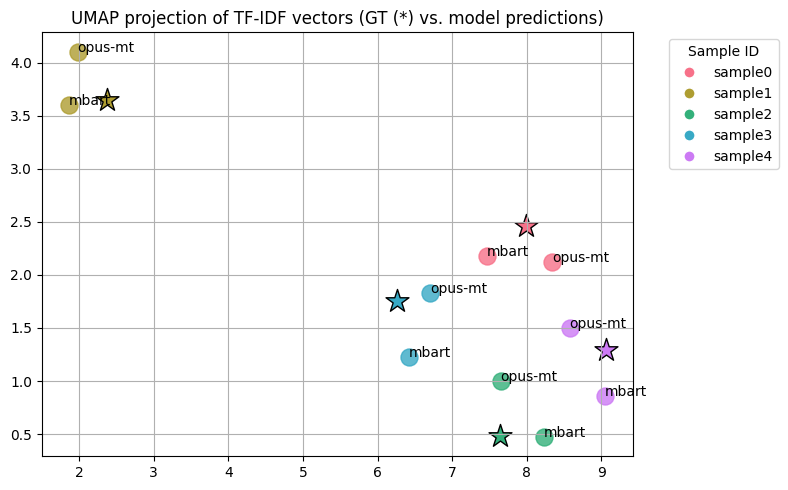

In [ ]:
# 2. TF-IDF 向量化
vectorizer = TfidfVectorizer(lowercase=True, stop_words=None, max_features=20_000)
X = vectorizer.fit_transform(sentences)   # shape: (n_sent, n_features)
fontsize = 10
S = 150

# 3. UMAP 降维
reducer = umap.UMAP(n_neighbors=5, min_dist=0.1, metric="cosine", random_state=42)
XY = reducer.fit_transform(X)             # shape: (n_sent, 2)

# 4. 画图
plt.figure(figsize=(8, 5))
unique_samples = sorted(set(labels))
palette = sns.color_palette("husl", n_colors=len(unique_samples))
color_map = {sam: palette[i] for i, sam in enumerate(unique_samples)}

for i, (x, y) in enumerate(XY):
    color = color_map[labels[i]]
    if markers[i] == "gt":        # 五角星
        plt.scatter(x, y, marker="*", s=S*2, c=[color], edgecolor="black")
    else:                         # 模型预测
        plt.scatter(x, y, c=[color], s=S, alpha=0.8)
        # 在点旁边写模型名（只写一次，防止重叠）
        plt.text(x, y, markers[i], fontsize=fontsize, ha="left")

# 图例：颜色 = 样本 ID
legend_elements = [plt.Line2D([0], [0], marker="o", color="w",
                              markerfacecolor=color_map[sam], markersize=8, label=sam)
                   for sam in unique_samples]
plt.legend(handles=legend_elements, title="Sample ID", bbox_to_anchor=(1.05, 1), fontsize=fontsize, loc="upper left")
plt.title("UMAP projection of TF-IDF vectors (GT (*) vs. model predictions)")
plt.tight_layout()
plt.grid(True)
plt.savefig('./cluster.jpg')

In [ ]:
vectorizer.vocabulary_

{'we': np.int64(121),
 'were': np.int64(122),
 'appalled': np.int64(10),
 'and': np.int64(8),
 'shocked': np.int64(101),
 'by': np.int64(22),
 'the': np.int64(111),
 'incident': np.int64(62),
 'are': np.int64(11),
 'greatly': np.int64(55),
 'astonished': np.int64(13),
 'to': np.int64(117),
 'learn': np.int64(71),
 'of': np.int64(83),
 'this': np.int64(116),
 'surprised': np.int64(106),
 'family': np.int64(47),
 'yobs': np.int64(129),
 'left': np.int64(73),
 'their': np.int64(112),
 'council': np.int64(29),
 'house': np.int64(59),
 'with': np.int64(125),
 '50': np.int64(1),
 '000': np.int64(0),
 'worth': np.int64(126),
 'damage': np.int64(30),
 'after': np.int64(5),
 'they': np.int64(114),
 'evicted': np.int64(42),
 'for': np.int64(51),
 'terrorising': np.int64(109),
 'neighbours': np.int64(81),
 'rogue': np.int64(98),
 'that': np.int64(110),
 'was': np.int64(120),
 'expelled': np.int64(45),
 'over': np.int64(87),
 'fears': np.int64(49),
 'intimidation': np.int64(65),
 'from': np.int64(

In [ ]:
df.head()

,tgt,src,mbart,opus-mt
0,We were appalled and shocked by the incident.,得知这一事件，我们感到大吃一惊。,We are greatly astonished to learn of this inc...,We were surprised to learn of the incident.
1,A family of yobs left their council house with...,因恐吓邻居而遭驱逐的一户流氓家庭，在离开前对其所住廉租房进行了破坏，造成了50000英镑的损失。,A rogue family that was expelled over fears of...,The family of rogues who had been evicted from...
2,The Olympics achieved huge benefits for Stratf...,奥运会使斯特拉特福德和东区受益匪浅。,The Olympics have done Stratford and the Easte...,The Olympic Games would greatly benefit Stratf...
3,Expanding the interpersonal relationship circl...,扩大人际关系圈，更平等地对话，避免社交顾虑，才是我们越发深爱线上聊的主要原因。,"Broadening the circle of relationships, engagi...","Broadening the circle of relationships, more e..."
4,"From these factors, it is quite normal to have...",从这些因素来看，7月份部分指标出现波动也是很正常，也是在预期之中。,"In light of these factors, fluctuations in som...","In the light of these factors, fluctuations in..."


In [ ]:
df.mbart

0    We are greatly astonished to learn of this inc...
1    A rogue family that was expelled over fears of...
2    The Olympics have done Stratford and the Easte...
3    Broadening the circle of relationships, engagi...
4    In light of these factors, fluctuations in som...
Name: mbart, dtype: object